# Импрорты и нужные классы

In [2]:
import sys
import os
import torch
import numpy as np
from dotenv import load_dotenv

sys.path.append('..')
env_file = os.path.join('..', '.env')
load_dotenv(env_file)
# name_dataset = os.environ['NAME_DATASET']
# name_test_dataset = os.environ['NAME_TEST_DATASET']
# dataset_path = os.environ['DATASET_PATH']
# test_path = os.environ['TEST_PATH']
# test_coco_path = os.environ['TEST_COCO_PATH']
# coco_path = os.environ['COCO_PATH']
# cache_pdf = os.environ['CASH_PDF_PATH']

doclaynet_train_pdf_path = os.environ['DOCLAYNET_TRAIN_PDF_PATH']
doclaynet_coco_path = os.environ['DOCLAYNET_COCO_PATH']
doclaynet_test_pdf_path = os.environ['DOCLAYNET_TEST_PDF_PATH']
doclaynet_test_coco_path_for_doc = os.environ['DOCLAYNET_TEST_COCO_PATH_FOR_DOC']
#запустить скрипт doc2pub для создания coco аннотации с метками как в publaynet
doclaynet_test_coco_path_for_pub = os.environ['DOCLAYNET_TEST_COCO_PATH_FOR_PUB']
doclaynet_train_cash_pdf_path = os.environ['DOCLAYNET_TRAIN_CASH_PDF_PATH']
doclaynet_test_cash_pdf_path_for_doc = os.environ['DOCLAYNET_TEST_CASH_PDF_PATH_FOR_DOC']
doclaynet_test_cash_pdf_path_for_pub = os.environ['DOCLAYNET_TEST_CASH_PDF_PATH_FOR_PUB']

publaynet_train_pdf_path = os.environ['PUBLAYNET_TRAIN_PDF_PATH']
publaynet_coco_path = os.environ['PUBLAYNET_COCO_PATH']
publaynet_test_pdf_path = os.environ['PUBLAYNET_TEST_PDF_PATH']
publaynet_test_coco_path = os.environ['PUBLAYNET_TEST_COCO_PATH']
publaynet_train_cash_pdf_path = os.environ['PUBLAYNET_TRAIN_CASH_PDF_PATH']
publaynet_test_cash_pdf_path = os.environ['PUBLAYNET_TEST_CASH_PDF_PATH']

In [3]:
from rows2regionsGLAM.utils.pdf_manager import PDFManager
from rows2regionsGLAM.utils.loger import Loger
from rows2regionsGLAM.utils.row_manager import RowManager
from rows2regionsGLAM.utils.ploter import Ploter
from rows2regionsGLAM.utils.trainer import Trainer
from rows2regionsGLAM.utils.tester import Tester
from rows2regionsGLAM.utils.cacher import Cacher
from rows2regionsGLAM.utils.coco_manager import COCOManager
from rows2regionsGLAM.utils.imbalance import calculate_imbalance
from rows2regionsGLAM.utils.tester import collect_maps, print_map_table

from rows2regionsGLAM.tokenizers import RowGLAMTokenizer
from rows2regionsGLAM.converters import Rows2Regions
from rows2regionsGLAM.datasetloaders.base_line_dataset import GLAMDataset
from rows2regionsGLAM.models.rowGLAM import TagModule, NodeGLAM, EdgeGLAM, CustomLoss, TorchModel
from rows2regionsGLAM.metrics import GridMetric
from pager.page_model.sub_models.dtype import ImageSegment
from pager.page_model.sub_models import BaseConverter, RegionModel, RowsModel
from torchmetrics.detection.mean_ap import MeanAveragePrecision

E:\Work\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
loger = Loger('log.txt')
pdf_manager = PDFManager(conf={"loger": loger, "pdf_reader": "PDFMiner"})
row_manager = RowManager(conf={"loger": loger, "add_image": True})

pub_coco_manager = COCOManager(conf={"loger": loger, "coco_path": publaynet_coco_path})
doc_coco_manager = COCOManager(conf={"loger": loger, "coco_path": doclaynet_coco_path})

ploter = Ploter(conf={"loger": loger})
tokenizer = RowGLAMTokenizer()
loger(tokenizer.get_name())

pdf2torch_dict = Cacher({
    "loger": loger,
    "pdf_manager": pdf_manager,
    "row_manager": row_manager,
    "tokenizer": tokenizer
})

# PubLayNet

In [4]:
json_true_regions, PUB_CLASSES = pub_coco_manager.get_regions_from_json()

In [5]:
PUB_CLASSES[3] = "text"
PUB_CLASSES

{1: 'text', 2: 'title', 3: 'text', 4: 'table', 5: 'figure', 0: 'other'}

In [6]:
file_names = list(json_true_regions.keys())
file_names.sort()

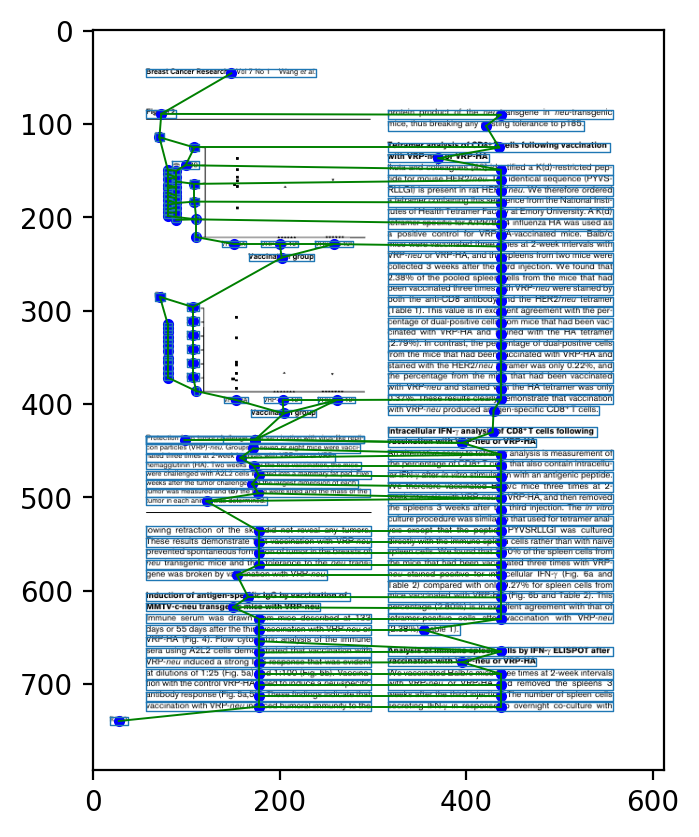

In [7]:
# отрисовка, проверка работы менеджеров
num_file = 1
file_name = file_names[num_file]
dataset_file = os.path.join(publaynet_train_pdf_path, file_name)
pdf_json, pdf_img = pdf_manager.get_json_and_img_from_pdf(dataset_file, num_page=0)
row_json = row_manager.get_row_json_from_pdf_json(pdf_json)
torch_dict = tokenizer(row_json, pdf_img)
ploter.set_dpi(200)
ploter.plot_img(pdf_img)
ploter.plot_tokens(tokenizer, torch_dict)

## Сохранение датасета

In [8]:
pub_dataset = GLAMDataset({
    "loger": loger,
    "pdf_dir": publaynet_train_pdf_path,
    "coco_file": publaynet_coco_path,
    "count_class": len(PUB_CLASSES),
    "name_dataset": "publaynet",
    "default_index": 0,
    "cache_dir": publaynet_train_cash_pdf_path,
    "pdf2torch_dict": pdf2torch_dict
})

# Создание Cache
N = len(pub_dataset)
for i, d in enumerate(pub_dataset):
    print(f"{(i+1)/N*100:4.2f} %", end='\r')

100.00 %

## Отрисовска файла из датасета

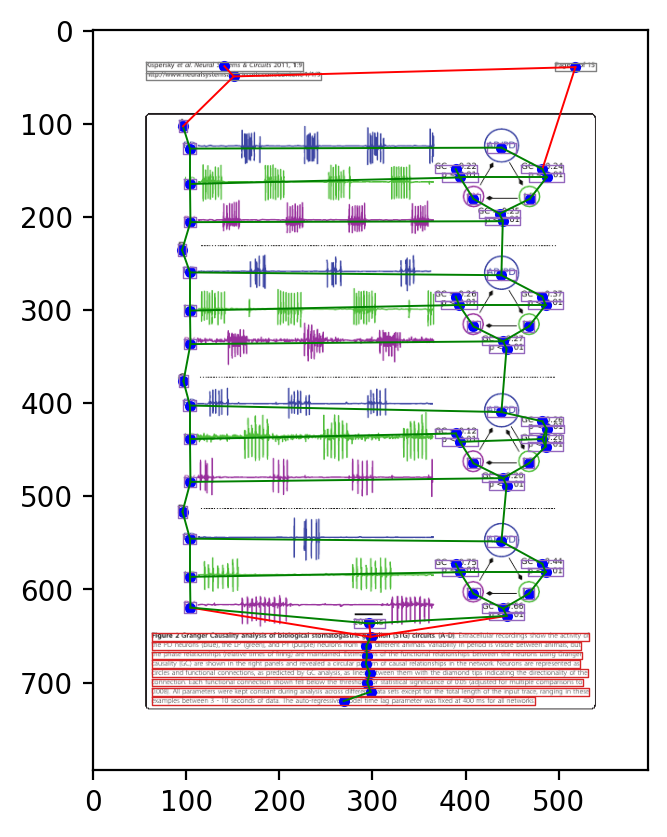

In [9]:
torch_dict_pub_train = pub_dataset[1050]
path_pdf = os.path.join(publaynet_train_pdf_path, torch_dict_pub_train['file_name'] + ".pdf")
_, img = pdf_manager.get_json_and_img_from_pdf(path_pdf)
ploter.set_dpi(200)
ploter.plot_img(img)
ploter.plot_tokens(tokenizer, torch_dict_pub_train, markup=True)

## Параметры модели

In [10]:
PUB_GLAM_MODEL = 'pub_row2region_GLAM_artic'
PUB_PARAMS  = {
    "node_featch": 15,
    "edge_featch": 4,
    "epochs": 30,
    "batch_size": 128,
    "learning_rate": 0.001,
    "Tag":[  {'in': -1, 'size': 512, 'out': 512, 'k': 3},
            {'in': 512, 'size': 256, 'out': 256, 'k': 3},
            # {'in': 256, 'size': 128, 'out': 128, 'k': 3},
            # {'in': 64, 'size': 32, 'out': 16, 'k': 3},
            ],
    "NodeLinear": [-1, 64, 32],
    "NodeLinearClassifier": [-1, 16, 8],
    "EdgeLinear": [-1, 16, 4],
    "batchNormNode": True,
    "batchNormEdge": True,
    "seg_k": 0.5,
    "loss_params": {
        "edge_coef": 0.8,
        "node_coef": 0.2,
    },
    "sigmoidEdge": False,
    "NodeClasses": len(PUB_CLASSES)
}

In [11]:
# Дисбаланс классов ------------------------------------
publaynet_imbalance, edge_imbalance = calculate_imbalance(pub_dataset)

print(publaynet_imbalance, edge_imbalance)

PUB_PARAMS['loss_params']['publaynet_imbalance'] = publaynet_imbalance
PUB_PARAMS['loss_params']['edge_imbalance'] = edge_imbalance

PUB_PARAMS

[0.07904524356126785, 0.0074686817824840546, 0.4100709557533264, 0.29622960090637207, 0.017031226307153702, 0.1901542693376541] 0.3825925588607788


{'node_featch': 15,
 'edge_featch': 4,
 'epochs': 30,
 'batch_size': 128,
 'learning_rate': 0.001,
 'Tag': [{'in': -1, 'size': 512, 'out': 512, 'k': 3},
  {'in': 512, 'size': 256, 'out': 256, 'k': 3}],
 'NodeLinear': [-1, 64, 32],
 'NodeLinearClassifier': [-1, 16, 8],
 'EdgeLinear': [-1, 16, 4],
 'batchNormNode': True,
 'batchNormEdge': True,
 'seg_k': 0.5,
 'loss_params': {'edge_coef': 0.8,
  'node_coef': 0.2,
  'publaynet_imbalance': [0.07904524356126785,
   0.0074686817824840546,
   0.4100709557533264,
   0.29622960090637207,
   0.017031226307153702,
   0.1901542693376541],
  'edge_imbalance': 0.3825925588607788},
 'sigmoidEdge': False,
 'NodeClasses': 6}

## Обучение модели

In [37]:
# model:torch.nn.Module = TorchModel(PUB_PARAMS)
# total_params = sum(p.numel() for p in model.parameters())  
# print(f"Number of parameters: {total_params}") 

In [18]:
trainer_pub = Trainer(conf={"loger": loger, "params": PUB_PARAMS, "model_name": PUB_GLAM_MODEL})
trainer_pub.start_train(5, pub_dataset)


            DATASET INFO:
            count row: 10000
            first: dict_keys(['N', 'X', 'Y', 'inds', 'true_edges', 'true_nodes', 'sp_A', 'file_name'])
            	 A:torch.Size([104, 104])
            	 nodes_feature:torch.Size([104, 15])
            	 edges_feature:torch.Size([151, 4])
            	 true_edges:torch.Size([151])
            end:dict_keys(['N', 'X', 'Y', 'inds', 'true_edges', 'true_nodes', 'sp_A', 'file_name'])
            	 A:torch.Size([107, 107])
            	 nodes_feature:torch.Size([107, 15])
            	 edges_feature:torch.Size([108, 4])
            	 true_edges:torch.Size([108])
        node_featch:	15
edge_featch:	4
epochs:	30
batch_size:	128
learning_rate:	0.001
Tag:	[{'in': 15, 'size': 512, 'out': 512, 'k': 3}, {'in': 512, 'size': 256, 'out': 256, 'k': 3}]
NodeLinear:	[271, 64, 32]
NodeLinearClassifier:	[32, 16, 8]
EdgeLinear:	[98, 16, 4]
batchNormNode:	True
batchNormEdge:	True
seg_k:	0.5
loss_params:	{'edge_coef': 0.8, 'node_coef': 0.2, 'publaynet

E:\Work\env\Lib\site-packages\torch_geometric\utils\_spmm.py:66: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  warnings.warn(f"Converting sparse tensor to CSR format for more "
E:\Work\env\Lib\site-packages\torch_geometric\utils\_spmm.py:70: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\SparseCsrTensorImpl.cpp:55.)
  src = src.to_sparse_csr()
E:\Work\env\Lib\site-packages\torch\nn\modules\module.py:1739: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


Время обучения batch'а 2.13 сек                                   
'X'62 % Batch loss=0.3802                                         
'X'41 % Batch loss=0.2369                                         
'X'62 % Batch loss=0.1979                                         
'X'12 % Batch loss=0.2189                                         
'X'3 % Batch loss=0.3250                                          
'X'69 % Batch loss=0.1481                                         
'X'53 % Batch loss=0.2056                                         
'X'28 % Batch loss=0.1449                                         
========== EPOCH #1 ========== (0.2727/0.1946)                    
Время обучения epoch 92.78 сек
'X'62 % Batch loss=0.1508                                         
'X'41 % Batch loss=0.1463                                         
'X'62 % Batch loss=0.0912                                         
'X'12 % Batch loss=0.1111                                         
'X'3 % Batch loss=0.1775       

# DocLayNet

In [12]:
json_true_regions, DOC_CLASSES = doc_coco_manager.get_regions_from_json()

In [13]:
# DOC_CLASSES[3] = "text"
DOC_CLASSES

{1: 'Caption',
 2: 'Footnote',
 3: 'Formula',
 4: 'List-item',
 5: 'Page-footer',
 6: 'Page-header',
 7: 'Picture',
 8: 'Section-header',
 9: 'Table',
 10: 'Text',
 11: 'Title',
 0: 'other'}

In [14]:
file_names = list(json_true_regions.keys())
file_names.sort()

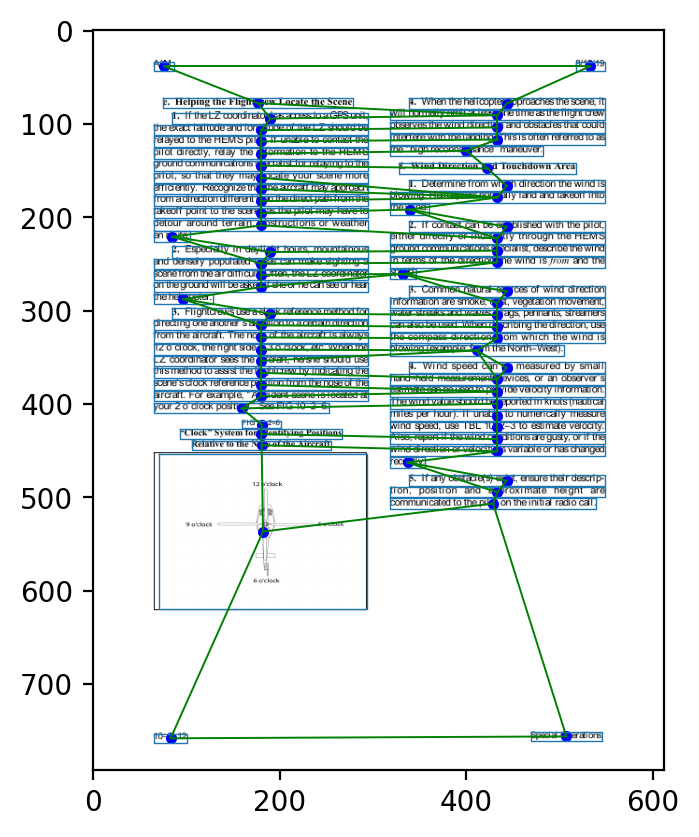

In [15]:
# отрисовка, проверка работы менеджеров
num_file = 1
file_name = file_names[num_file]
dataset_file = os.path.join(doclaynet_train_pdf_path, file_name)
pdf_json, pdf_img = pdf_manager.get_json_and_img_from_pdf(dataset_file, num_page=0)
row_json = row_manager.get_row_json_from_pdf_json(pdf_json)
torch_dict = tokenizer(row_json, pdf_img)
ploter.set_dpi(200)
ploter.plot_img(pdf_img)
ploter.plot_tokens(tokenizer, torch_dict)

## Сохранение датасета

In [16]:
doc_dataset = GLAMDataset({
    "loger": loger,
    "pdf_dir": doclaynet_train_pdf_path,
    "coco_file": doclaynet_coco_path,
    "count_class": len(DOC_CLASSES),
    "name_dataset": "doclaynet",
    "default_index": 0,
    "cache_dir": doclaynet_train_cash_pdf_path,
    "pdf2torch_dict": pdf2torch_dict
})

# Создание Cache
N = len(doc_dataset)
for i, d in enumerate(doc_dataset):
    print(f"{(i+1)/N*100:4.2f} %", end='\r')

100.00 %

## Отрисовска файла из датасета

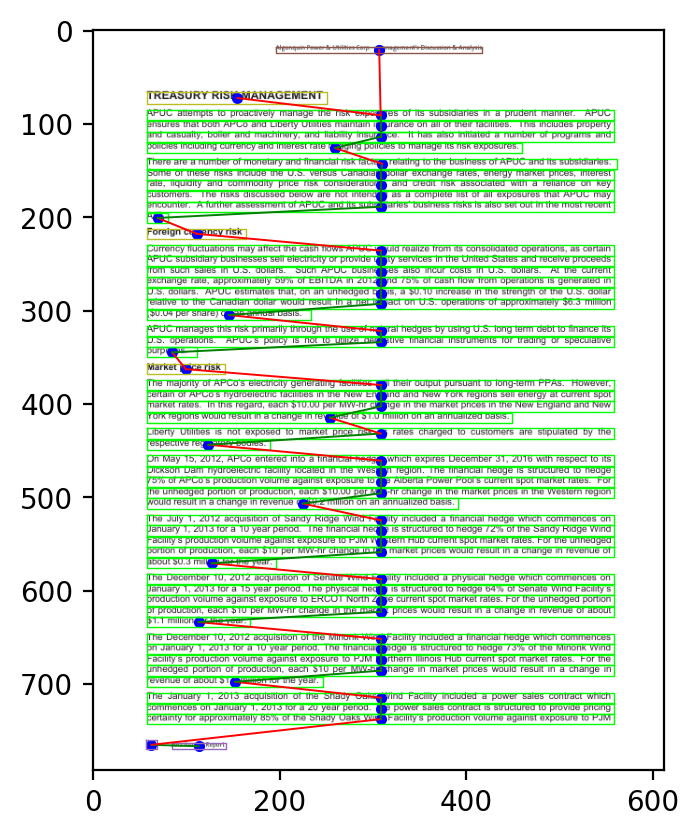

In [17]:
torch_dict_doc_train = doc_dataset[100]
path_pdf = os.path.join(doclaynet_train_pdf_path, torch_dict_doc_train['file_name'] + ".pdf")
_, img = pdf_manager.get_json_and_img_from_pdf(path_pdf)
ploter.set_dpi(200)
ploter.plot_img(img)
ploter.plot_tokens(tokenizer, torch_dict_doc_train, markup=True)

## Параметры модели

In [18]:
DOC_GLAM_MODEL = 'doc_row2region_GLAM_artic'
DOC_PARAMS  = {
    "node_featch": 15,
    "edge_featch": 4,
    "epochs": 30,
    "batch_size": 128,
    "learning_rate": 0.001,
    "Tag":[  {'in': -1, 'size': 512, 'out': 512, 'k': 3},
            {'in': 512, 'size': 256, 'out': 256, 'k': 3},
            # {'in': 256, 'size': 128, 'out': 128, 'k': 3},
            # {'in': 64, 'size': 32, 'out': 16, 'k': 3},
            ],
    "NodeLinear": [-1, 64, 32],
    "NodeLinearClassifier": [-1, 16, 8],
    "EdgeLinear": [-1, 16, 4],
    "batchNormNode": True,
    "batchNormEdge": True,
    "seg_k": 0.5,
    "loss_params": {
        "edge_coef": 0.8,
        "node_coef": 0.2,
    },
    "sigmoidEdge": False,
    "NodeClasses": len(DOC_CLASSES)
}

In [19]:
# Дисбаланс классов ------------------------------------
publaynet_imbalance, edge_imbalance = calculate_imbalance(doc_dataset)

print(publaynet_imbalance, edge_imbalance)

DOC_PARAMS['loss_params']['publaynet_imbalance'] = publaynet_imbalance
DOC_PARAMS['loss_params']['edge_imbalance'] = edge_imbalance

DOC_PARAMS

[0.039360400289297104, 0.05318712443113327, 0.2527250349521637, 0.008588756434619427, 0.006679039914160967, 0.0379040464758873, 0.021431939676404, 0.009329712018370628, 0.01933765970170498, 0.0012496041599661112, 0.0008077235543169081, 0.5493989586830139] 0.3447810759222469


{'node_featch': 15,
 'edge_featch': 4,
 'epochs': 30,
 'batch_size': 128,
 'learning_rate': 0.001,
 'Tag': [{'in': -1, 'size': 512, 'out': 512, 'k': 3},
  {'in': 512, 'size': 256, 'out': 256, 'k': 3}],
 'NodeLinear': [-1, 64, 32],
 'NodeLinearClassifier': [-1, 16, 8],
 'EdgeLinear': [-1, 16, 4],
 'batchNormNode': True,
 'batchNormEdge': True,
 'seg_k': 0.5,
 'loss_params': {'edge_coef': 0.8,
  'node_coef': 0.2,
  'publaynet_imbalance': [0.039360400289297104,
   0.05318712443113327,
   0.2527250349521637,
   0.008588756434619427,
   0.006679039914160967,
   0.0379040464758873,
   0.021431939676404,
   0.009329712018370628,
   0.01933765970170498,
   0.0012496041599661112,
   0.0008077235543169081,
   0.5493989586830139],
  'edge_imbalance': 0.3447810759222469},
 'sigmoidEdge': False,
 'NodeClasses': 12}

## Обучение модели

In [60]:
# model:torch.nn.Module = TorchModel(PUB_PARAMS)
# total_params = sum(p.numel() for p in model.parameters())  
# print(f"Number of parameters: {total_params}") 

In [ ]:
trainer_doc = Trainer(conf={"loger": loger, "params": DOC_PARAMS, "model_name": DOC_GLAM_MODEL})
trainer_doc.start_train(5, doc_dataset)


            DATASET INFO:
            count row: 10000
            first: dict_keys(['N', 'X', 'Y', 'inds', 'true_edges', 'true_nodes', 'sp_A', 'file_name'])
            	 A:torch.Size([1, 1])
            	 nodes_feature:torch.Size([1, 15])
            	 edges_feature:torch.Size([0])
            	 true_edges:torch.Size([0])
            end:dict_keys(['N', 'X', 'Y', 'inds', 'true_edges', 'true_nodes', 'sp_A', 'file_name'])
            	 A:torch.Size([105, 105])
            	 nodes_feature:torch.Size([105, 15])
            	 edges_feature:torch.Size([142, 4])
            	 true_edges:torch.Size([142])
        node_featch:	15
edge_featch:	4
epochs:	30
batch_size:	128
learning_rate:	0.001
Tag:	[{'in': -1, 'size': 512, 'out': 512, 'k': 3}, {'in': 512, 'size': 256, 'out': 256, 'k': 3}]
NodeLinear:	[-1, 64, 32]
NodeLinearClassifier:	[-1, 16, 8]
EdgeLinear:	[-1, 16, 4]
batchNormNode:	True
batchNormEdge:	True
seg_k:	0.5
loss_params:	{'edge_coef': 0.8, 'node_coef': 0.2, 'publaynet_imbalance': [

# Проверка работы модели PubLayNet

In [20]:
PUB_PARAMS['sigmoidEdge'] = True
model_pub = TorchModel(PUB_PARAMS)
model_pub.load_state_dict(torch.load(PUB_GLAM_MODEL, weights_only=True))

rows_model = RowsModel()
region_model = RegionModel()
rows2regions_pub = Rows2Regions({
    'model':model_pub, 
    'tokenizer': RowGLAMTokenizer(),
    'is_merge_extract': True,
    'classes': PUB_CLASSES
})

E:\Work\env\Lib\site-packages\torch_geometric\utils\_spmm.py:66: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  warnings.warn(f"Converting sparse tensor to CSR format for more "
E:\Work\env\Lib\site-packages\torch_geometric\utils\_spmm.py:70: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\SparseCsrTensorImpl.cpp:55.)
  src = src.to_sparse_csr()
E:\Work\env\Lib\site-packages\torch\nn\modules\module.py:1739: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


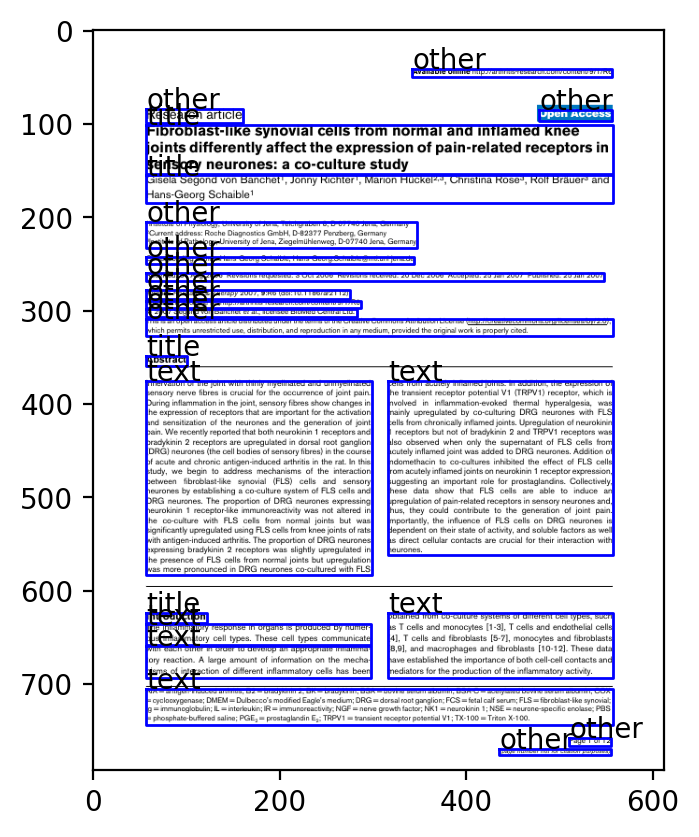

In [21]:
torch_dict_pub_train = pub_dataset[100]
path_pdf = os.path.join(publaynet_train_pdf_path, torch_dict_pub_train['file_name'] + ".pdf")
pdf_json, img = pdf_manager.get_json_and_img_from_pdf(path_pdf)
ploter.set_dpi(200)
ploter.plot_img(img)
# ploter.plot_tokens(tokenizer, torch_dict_pub_train)

# Регионы --------------------------------------------------------------
row_json = row_manager.get_row_json_from_pdf_json(pdf_json)

rows_model.from_dict({"rows": row_json})
rows2regions_pub.convert(rows_model, region_model, img)

for reg in region_model.regions:
    reg.segment.plot(text=reg.label)

# Проверка работы модели DocLayNet

In [22]:
DOC_PARAMS['sigmoidEdge'] = True
model_doc = TorchModel(DOC_PARAMS)
model_doc.load_state_dict(torch.load(DOC_GLAM_MODEL, weights_only=True))

rows_model = RowsModel()
region_model = RegionModel()
rows2regions_doc = Rows2Regions({
    'model':model_doc, 
    'tokenizer': RowGLAMTokenizer(),
    'is_merge_extract': True,
    'classes': DOC_CLASSES
})

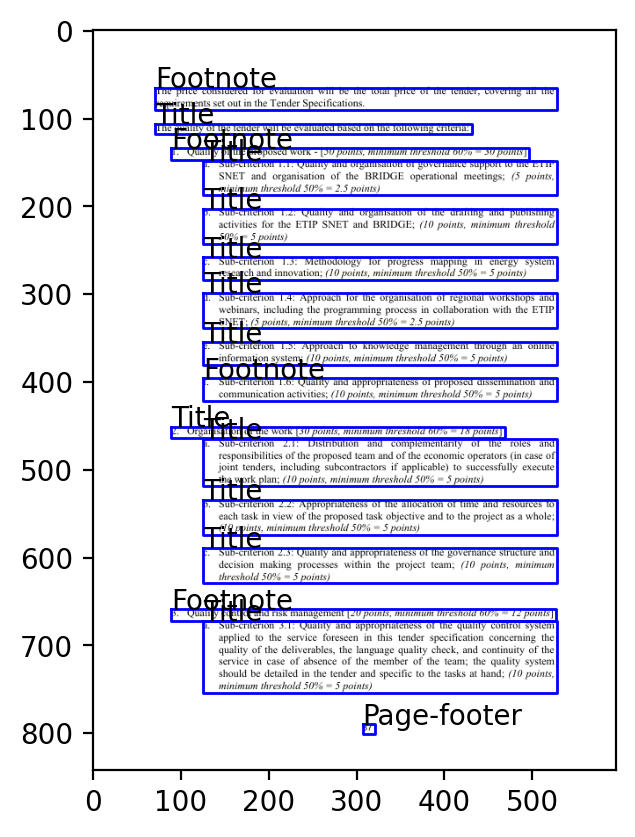

In [23]:
torch_dict_doc_train = doc_dataset[3000]
path_pdf = os.path.join(doclaynet_train_pdf_path, torch_dict_doc_train['file_name'] + ".pdf")
pdf_json, img = pdf_manager.get_json_and_img_from_pdf(path_pdf)
ploter.set_dpi(200)
ploter.plot_img(img)
# ploter.plot_tokens(tokenizer, torch_dict_doc_train)

# Регионы --------------------------------------------------------------
row_json = row_manager.get_row_json_from_pdf_json(pdf_json)

rows_model.from_dict({"rows": row_json})
rows2regions_doc.convert(rows_model, region_model, img)

for reg in region_model.regions:
    reg.segment.plot(text=reg.label)

# Тестирование 

## Создание тестовых датасетов

### publaynet test dataset 

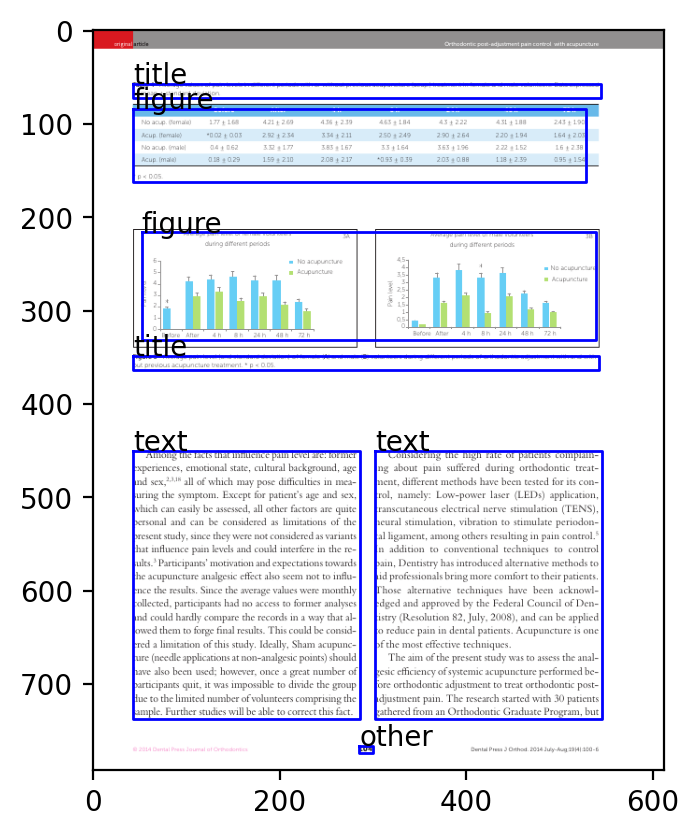

In [24]:
pub_test_dataset = GLAMDataset(
    {
    "loger": loger,
    "pdf_dir": publaynet_test_pdf_path,
    "coco_file": publaynet_test_coco_path,
    "count_class": len(PUB_CLASSES),
    "name_dataset": "publaynet",
    "default_index": 0,
    "cache_dir": publaynet_test_cash_pdf_path,
    "pdf2torch_dict": pdf2torch_dict
    }
)

torch_dict2 = pub_test_dataset[100]
path_pdf = os.path.join(publaynet_test_pdf_path, torch_dict2['file_name'] + ".pdf")
pdf_json, img = pdf_manager.get_json_and_img_from_pdf(path_pdf)
ploter.set_dpi(200)
ploter.plot_img(img)
# ploter.plot_tokens(tokenizer, torch_dict2)

# Регионы --------------------------------------------------------------
row_json = row_manager.get_row_json_from_pdf_json(pdf_json)

rows_model.from_dict({"rows": row_json})
rows2regions_pub.convert(rows_model, region_model, img)

for reg in region_model.regions:
    reg.segment.plot(text=reg.label)

In [25]:
loger("Start Test")
loger.time_log()

N = len(pub_test_dataset)
for i, d in enumerate(pub_test_dataset):
    print(f"{(i+1)/N*100:4.2f} %", end='\r')

100.00 %

### doclaynet test dataset for doclaynet

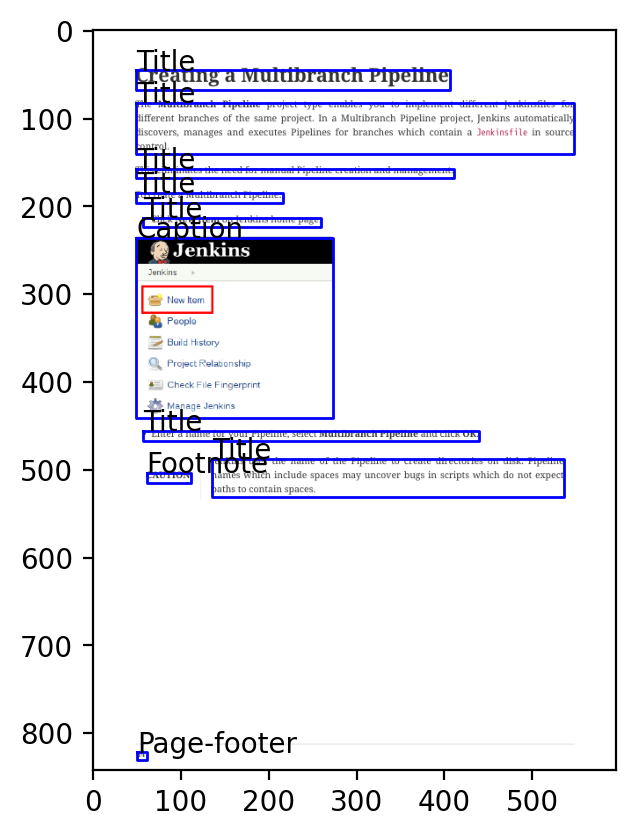

In [26]:
doc_test_dataset_for_doc = GLAMDataset(
    {
    "loger": loger,
    "pdf_dir": doclaynet_test_pdf_path,
    "coco_file": doclaynet_test_coco_path_for_doc,
    "count_class": len(DOC_CLASSES),
    "name_dataset": "doclaynet",
    "default_index": 0,
    "cache_dir": doclaynet_test_cash_pdf_path_for_doc,
    "pdf2torch_dict": pdf2torch_dict
    }
)

torch_dict2 = doc_test_dataset_for_doc[50]
path_pdf = os.path.join(doclaynet_test_pdf_path, torch_dict2['file_name'] + ".pdf")
pdf_json, img = pdf_manager.get_json_and_img_from_pdf(path_pdf)
ploter.set_dpi(200)
ploter.plot_img(img)
# ploter.plot_tokens(tokenizer, torch_dict2)

# Регионы --------------------------------------------------------------
row_json = row_manager.get_row_json_from_pdf_json(pdf_json)

rows_model.from_dict({"rows": row_json})
rows2regions_doc.convert(rows_model, region_model, img)

for reg in region_model.regions:
    reg.segment.plot(text=reg.label)

In [27]:
loger("Start Test")
loger.time_log()

N = len(doc_test_dataset_for_doc)
for i, d in enumerate(doc_test_dataset_for_doc):
    print(f"{(i+1)/N*100:4.2f} %", end='\r')

100.00 %

### doclaynet test dataset for publaynet

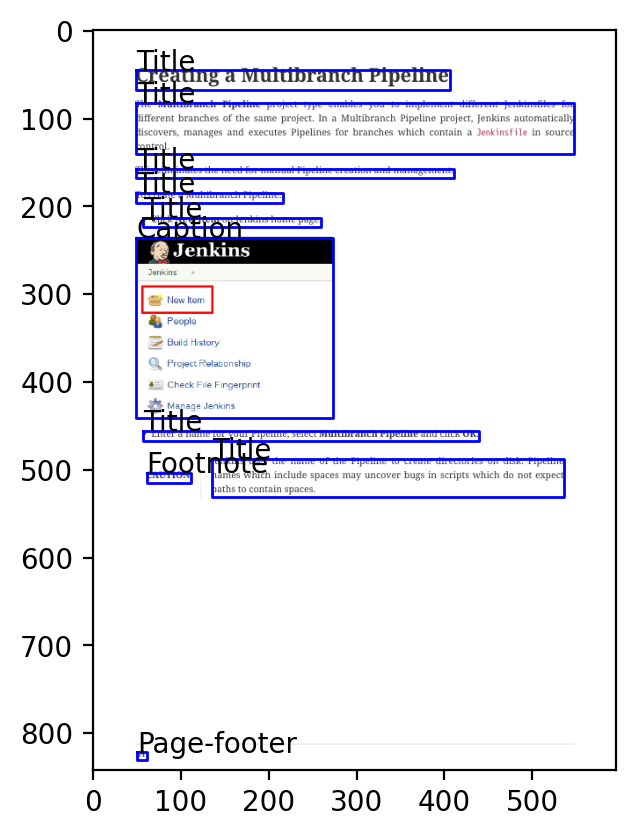

In [28]:
doc_test_dataset_for_pub = GLAMDataset(
    {
    "loger": loger,
    "pdf_dir": doclaynet_test_pdf_path,
    "coco_file": doclaynet_test_coco_path_for_pub,
    "count_class": len(DOC_CLASSES),
    "name_dataset": "doclaynet",
    "default_index": 0,
    "cache_dir": doclaynet_test_cash_pdf_path_for_pub,
    "pdf2torch_dict": pdf2torch_dict
    }
)

torch_dict2 = doc_test_dataset_for_pub[50]
path_pdf = os.path.join(doclaynet_test_pdf_path, torch_dict2['file_name'] + ".pdf")
pdf_json, img = pdf_manager.get_json_and_img_from_pdf(path_pdf)
ploter.set_dpi(200)
ploter.plot_img(img)
# ploter.plot_tokens(tokenizer, torch_dict2)

# Регионы --------------------------------------------------------------
row_json = row_manager.get_row_json_from_pdf_json(pdf_json)

rows_model.from_dict({"rows": row_json})
rows2regions_doc.convert(rows_model, region_model, img)

for reg in region_model.regions:
    reg.segment.plot(text=reg.label)

In [29]:
loger("Start Test")
loger.time_log()

N = len(doc_test_dataset_for_pub)
for i, d in enumerate(doc_test_dataset_for_pub):
    print(f"{(i+1)/N*100:4.2f} %", end='\r')

100.00 %

## Оценка

In [30]:
loger_train_pub_test_pub = Loger('log_train_pub_test_pub.txt')
loger_train_pub_test_doc = Loger('log_train_pub_test_doc.txt')
loger_train_doc_test_doc = Loger('log_train_doc_test_doc.txt')
loger_train_doc_test_pub = Loger('log_train_doc_test_pub.txt')

### Train pub Test pub

In [31]:
tester_train_pub_test_pub = Tester(conf={
    "loger": loger_train_pub_test_pub, 
    "pdf_manager": pdf_manager, 
    "row_manager": row_manager, 
    "rows_model": rows_model, 
    "region_model": region_model, 
    "rows2regions": rows2regions_pub})

metrics_pp = tester_train_pub_test_pub.calculate_target_and_preds(
    pub_test_dataset, 
    "publaynet", 
    "publaynet", 
    publaynet_train_pdf_path, 
    publaynet_test_pdf_path
)

35.50 %

Cannot set gray non-stroke color because /'P1' is an invalid float value
Cannot set gray non-stroke color because /'P2' is an invalid float value
Cannot set gray non-stroke color because /'P3' is an invalid float value
Cannot set gray non-stroke color because /'P4' is an invalid float value


45.00 %

Cannot set gray non-stroke color because /'P5' is an invalid float value
Cannot set gray non-stroke color because /'P6' is an invalid float value
Cannot set gray non-stroke color because /'P7' is an invalid float value
Cannot set gray non-stroke color because /'P8' is an invalid float value


54.50 %

Cannot set gray non-stroke color because /'P1' is an invalid float value
Cannot set gray non-stroke color because /'P2' is an invalid float value
Cannot set gray non-stroke color because /'P3' is an invalid float value
Cannot set gray non-stroke color because /'P3' is an invalid float value
Cannot set gray non-stroke color because /'P4' is an invalid float value
Cannot set gray non-stroke color because /'P4' is an invalid float value
Cannot set gray non-stroke color because /'P5' is an invalid float value
Cannot set gray non-stroke color because /'P5' is an invalid float value


100.00 %

### Train pub Test doc

In [32]:
tester_train_pub_test_doc = Tester(conf={
    "loger": loger_train_pub_test_doc, 
    "pdf_manager": pdf_manager, 
    "row_manager": row_manager, 
    "rows_model": rows_model, 
    "region_model": region_model, 
    "rows2regions": rows2regions_pub})

metrics_pd = tester_train_pub_test_doc.calculate_target_and_preds(
    doc_test_dataset_for_pub, 
    "publaynet", 
    "doclaynet", 
    publaynet_train_pdf_path, 
    doclaynet_test_pdf_path
)

27 55bc17a32c171e1efa89be1bb04619cac98ec1fece7986bf119891e4145c257e
34 61dac4cb4814a755d271cbacfb3c051927528f4dd49952d8a7056e1359533f02
36 62b2b9083388997db41c1397430165188d16bdec59b3fdf5175892b3cb7da21c
43 6bfd58c479687cbc2c5834555de0f64dd6bb820bc419f3c9b1a1cd1e67b9f2b0
61 96e7b57ddebc5fb55960335e6771f4d948532830c02dcf445e27a2864333a189
64 9d8f0c83605bd24c3f997f9e54f5c66fd0c9bc6e3e812ec569ce640521ae905c
69 b1f0d398e365070dadc2c560fa7ef90f19435762d37b7e787b75a3c0b11c2bc6
71 b6953846272754e54bbe6465b2a28697ef51c7efc30f13ee9c462f4e2018f67b
74 b9cc278329c412a8d5d7ac22070257ba53981c645dfbac1d859a35028c7ae723
86 d4000809affc277416845340c28c77f50422c4fdaeae41ed28ccc8e7e1d05367
100.00 %

### Train doc Test doc

In [33]:
tester_train_doc_test_doc = Tester(conf={
    "loger": loger_train_doc_test_doc, 
    "pdf_manager": pdf_manager, 
    "row_manager": row_manager, 
    "rows_model": rows_model, 
    "region_model": region_model, 
    "rows2regions": rows2regions_doc})

metrics_dd = tester_train_doc_test_doc.calculate_target_and_preds(
    doc_test_dataset_for_doc, 
    "doclaynet", 
    "doclaynet", 
    doclaynet_train_pdf_path, 
    doclaynet_test_pdf_path
)

27 55bc17a32c171e1efa89be1bb04619cac98ec1fece7986bf119891e4145c257e
34 61dac4cb4814a755d271cbacfb3c051927528f4dd49952d8a7056e1359533f02
36 62b2b9083388997db41c1397430165188d16bdec59b3fdf5175892b3cb7da21c
43 6bfd58c479687cbc2c5834555de0f64dd6bb820bc419f3c9b1a1cd1e67b9f2b0
61 96e7b57ddebc5fb55960335e6771f4d948532830c02dcf445e27a2864333a189
64 9d8f0c83605bd24c3f997f9e54f5c66fd0c9bc6e3e812ec569ce640521ae905c
69 b1f0d398e365070dadc2c560fa7ef90f19435762d37b7e787b75a3c0b11c2bc6
71 b6953846272754e54bbe6465b2a28697ef51c7efc30f13ee9c462f4e2018f67b
74 b9cc278329c412a8d5d7ac22070257ba53981c645dfbac1d859a35028c7ae723
86 d4000809affc277416845340c28c77f50422c4fdaeae41ed28ccc8e7e1d05367
100.00 %

### Train doc Test pub

In [34]:
tester_train_doc_test_pub = Tester(conf={
    "loger": loger_train_doc_test_pub, 
    "pdf_manager": pdf_manager, 
    "row_manager": row_manager, 
    "rows_model": rows_model, 
    "region_model": region_model, 
    "rows2regions": rows2regions_doc})

metrics_dp = tester_train_doc_test_pub.calculate_target_and_preds(
    pub_test_dataset, 
    "doclaynet", 
    "publaynet", 
    doclaynet_train_pdf_path, 
    publaynet_test_pdf_path
)

35.50 %

Cannot set gray non-stroke color because /'P1' is an invalid float value
Cannot set gray non-stroke color because /'P2' is an invalid float value
Cannot set gray non-stroke color because /'P3' is an invalid float value
Cannot set gray non-stroke color because /'P4' is an invalid float value


45.00 %

Cannot set gray non-stroke color because /'P5' is an invalid float value
Cannot set gray non-stroke color because /'P6' is an invalid float value
Cannot set gray non-stroke color because /'P7' is an invalid float value
Cannot set gray non-stroke color because /'P8' is an invalid float value


54.00 %

Cannot set gray non-stroke color because /'P1' is an invalid float value
Cannot set gray non-stroke color because /'P2' is an invalid float value
Cannot set gray non-stroke color because /'P3' is an invalid float value
Cannot set gray non-stroke color because /'P3' is an invalid float value
Cannot set gray non-stroke color because /'P4' is an invalid float value
Cannot set gray non-stroke color because /'P4' is an invalid float value


54.50 %

Cannot set gray non-stroke color because /'P5' is an invalid float value
Cannot set gray non-stroke color because /'P5' is an invalid float value


100.00 %

### Вывод результатов

In [35]:
print("train_pub_test_pub")
tester_train_pub_test_pub.print_result(metrics_pp)

print("train_pub_test_doc")
tester_train_pub_test_doc.print_result(metrics_pd)

print("train_doc_test_doc")
tester_train_doc_test_doc.print_result(metrics_dd)

print("train_doc_test_pub")
tester_train_doc_test_pub.print_result(metrics_dp)

train_pub_test_pub
mAP@IoU[0.50:0.95]   :0.36273867
threshold_05--------------------
precision_row       :0.8326
recall_row          :0.6779
f1_row              :0.7473
precision_word      :0.8017
recall_word         :0.6554
f1_word             :0.7212
threshold_95--------------------
precision_row       :0.6638
recall_row          :0.5405
f1_row              :0.5959
precision_word      :0.6374
recall_word         :0.5217
f1_word             :0.5738

train_pub_test_doc
mAP@IoU[0.50:0.95]   :0.11703727
threshold_05--------------------
precision_row       :0.7031
recall_row          :0.4435
f1_row              :0.5439
precision_word      :0.7020
recall_word         :0.4508
f1_word             :0.5490
threshold_95--------------------
precision_row       :0.4987
recall_row          :0.3252
f1_row              :0.3937
precision_word      :0.4836
recall_word         :0.3222
f1_word             :0.3867

train_doc_test_doc
mAP@IoU[0.50:0.95]   :0.26938343
threshold_05--------------------
preci

In [5]:
log_directory = "./"

table = collect_maps(log_directory)
print_map_table(table)

test\train   | PubLayNet  | DocLayNet 
--------------------------------------
PubLayNet    | 0.362739   | 0.180631  
DocLayNet    | 0.117037   | 0.269383  


In [ ]:
mAP@IoU[0.50:0.95]   :0.52044123
==================================================
threshold_05--------------------
precision_row       :0.8745
recall_row          :0.7442
f1_row              :0.8041
precision_word      :0.8312
recall_word         :0.7130
f1_word             :0.7676
threshold_95--------------------
precision_row       :0.7275
recall_row          :0.6222
f1_row              :0.6707
precision_word      :0.6884
recall_word         :0.5949
f1_word             :0.6382